In [1]:
import pandas as pd

data = pd.read_csv("../data/processed/combined_pond_dataset.csv")

data.head()

,created_at,temperature,turbidity,dissolved_oxygen,ph,ammonia,nitrate,pond
0,2021-06-18 12:11:39+00:00,NaN,97.0,7.329,8.48358,0.05393,0.0,9
1,2021-06-18 12:12:08+00:00,NaN,97.0,7.659,8.40641,0.13203,0.0,9
2,2021-06-18 12:12:28+00:00,NaN,96.0,11.230,8.41095,0.27792,0.0,9
3,2021-06-18 12:12:48+00:00,NaN,45.0,9.828,8.40641,0.04398,813.0,9
4,2021-06-18 12:13:07+00:00,NaN,45.0,9.623,8.40641,0.00052,1255.0,9


In [2]:
data.shape

(826630, 8)

In [3]:
data.columns

Index(['created_at', 'temperature', 'turbidity', 'dissolved_oxygen', 'ph',
       'ammonia', 'nitrate', 'pond'],
      dtype='str')

In [4]:
#convert timestamp
data["created_at"] = pd.to_datetime(data["created_at"])

In [5]:
data.dtypes

created_at          datetime64[us, UTC]
temperature                     float64
turbidity                       float64
dissolved_oxygen                float64
ph                              float64
ammonia                         float64
nitrate                         float64
pond                              int64
dtype: object

In [6]:
#sort time series in chronological order
data = data.sort_values("created_at")

In [7]:
import numpy as np
data = data.replace([np.inf, -np.inf], np.nan)

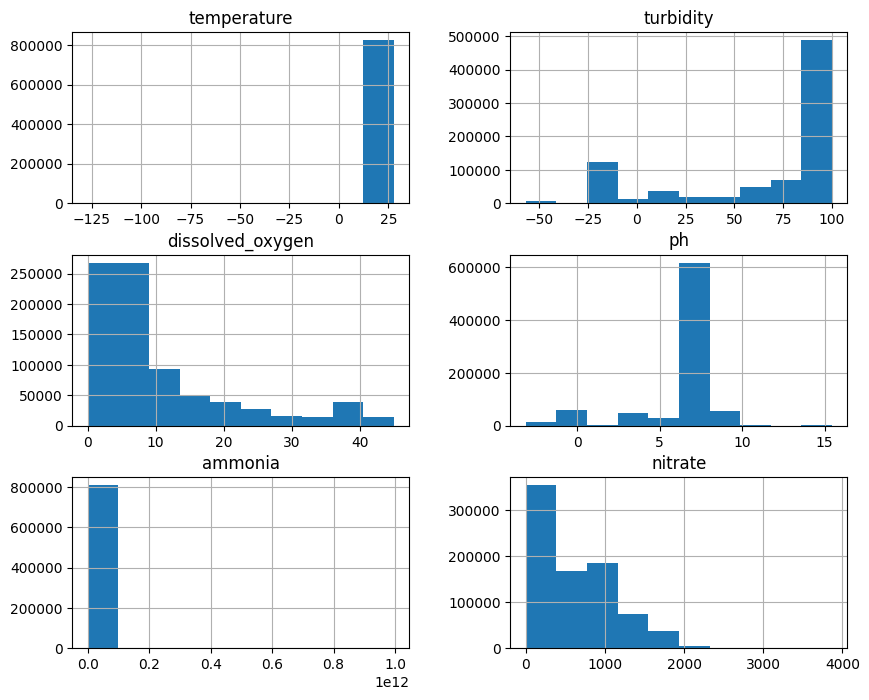

In [8]:
#distribution of water parameters
import matplotlib.pyplot as plt

data[[
    "temperature",
    "turbidity",
    "dissolved_oxygen",
    "ph",
    "ammonia",
    "nitrate"
]].hist(figsize=(10,8))

plt.show()

| Variable    | Issue                       | Severity    | Fix           |
| ----------- | --------------------------- | ----------- | ------------- |
| Ammonia     | Extreme outliers (1e12)     | 🔴 Critical | Remove / cap  |
| Turbidity   | Negative values             | 🔴 Critical | Filter        |
| DO          | Unrealistically high values | 🟠 Moderate | Cap           |
| pH          | Slight out-of-range         | 🟡 Minor    | Clip          |
| Nitrate     | Skewed distribution         | 🟡 Minor    | Log transform |
| Temperature | OK                          | 🟢 Clean    | Keep          |

The exploratory data analysis reveals that while some parameters such as temperature and pH fall within expected operational ranges for aquaponics systems, several variables exhibit significant data quality issues and non-normal distributions. Notably, ammonia and turbidity contain extreme and invalid values (e.g., excessively large magnitudes and negative readings), indicating potential sensor errors or data logging inconsistencies inherent in IoT-based monitoring systems. Dissolved oxygen and nitrate also display high variability and skewness, suggesting the presence of outliers and non-linear environmental dynamics. Overall, the dataset reflects both the complexity of aquatic ecosystems and the limitations of real-world sensor data, reinforcing the need for thorough data cleaning and supporting the study’s premise of non-linear performance behavior and threshold effects in aquaponics environments.

SECOND EDA

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("../data/processed/cleaned_dataset.csv")

# Convert time
data['created_at'] = pd.to_datetime(data['created_at'])

data.head()

,created_at,temperature,turbidity,dissolved_oxygen,ph,ammonia,nitrate,pond
0,2021-06-19 00:00:05+00:00,24.875000,93.666667,4.5050,8.43365,0.38000,5.267858,2
1,2021-06-19 00:00:05+00:00,24.875000,100.000000,4.5050,8.43365,0.45842,5.267858,1
2,2021-06-19 00:00:06+00:00,24.883929,87.333333,6.2250,8.14766,5.53454,6.090178,7
3,2021-06-19 00:00:26+00:00,24.901786,80.000000,4.1950,7.09450,4.53072,4.744932,3
4,2021-06-19 00:00:27+00:00,24.910714,80.500000,5.5415,8.14766,7.87051,5.976351,7


In [10]:
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 269709 entries, 0 to 269708
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype              
---  ------            --------------   -----              
 0   created_at        269709 non-null  datetime64[us, UTC]
 1   temperature       269709 non-null  float64            
 2   turbidity         269709 non-null  float64            
 3   dissolved_oxygen  269709 non-null  float64            
 4   ph                269709 non-null  float64            
 5   ammonia           269709 non-null  float64            
 6   nitrate           269709 non-null  float64            
 7   pond              269709 non-null  int64              
dtypes: datetime64[us, UTC](1), float64(6), int64(1)
memory usage: 16.5 MB


,temperature,turbidity,dissolved_oxygen,ph,ammonia,nitrate,pond
count,269709.000000,269709.000000,269709.000000,269709.000000,269709.000000,269709.000000,269709.000000
mean,24.444360,91.502003,6.208282,7.364073,1.127669,6.068833,4.172282
std,0.700815,17.888765,4.134202,0.705275,2.057529,1.062042,2.775285
min,2.220588,0.000000,0.007000,0.003860,0.000000,0.000000,1.000000
25%,23.937500,93.000000,3.414000,7.139900,0.122615,4.882802,2.000000
50%,24.437500,97.333333,5.080000,7.366870,0.389150,6.558198,3.000000
75%,24.872396,100.000000,8.367000,7.607460,0.692500,6.851185,7.000000
max,27.812500,100.000000,20.000000,13.427060,9.999835,8.261268,11.000000


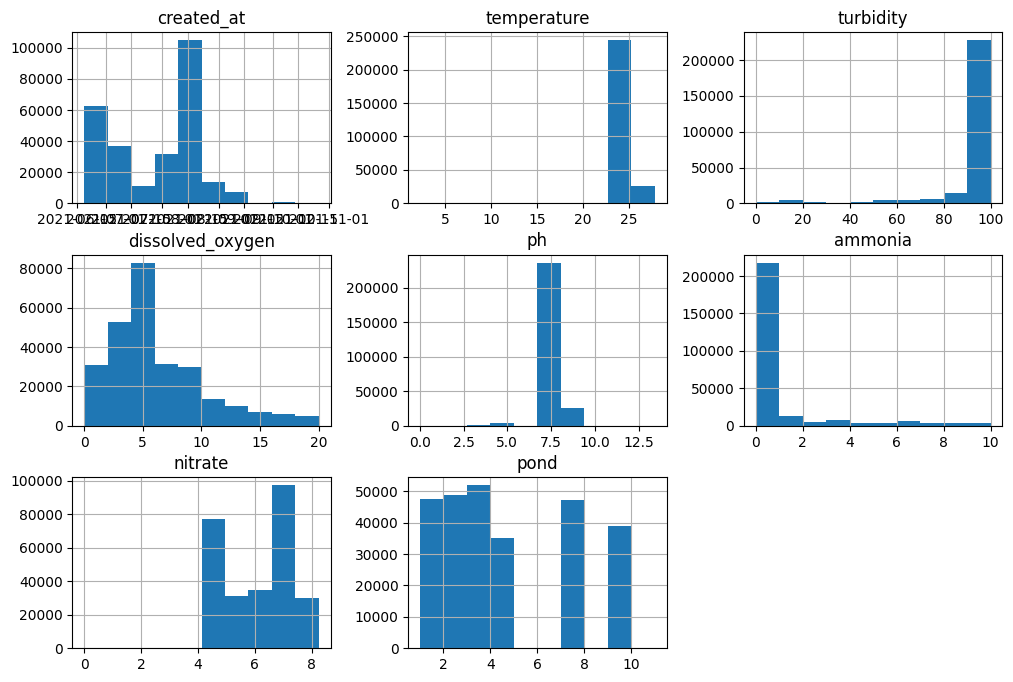

In [11]:
data.hist(figsize=(12,8))
plt.show()

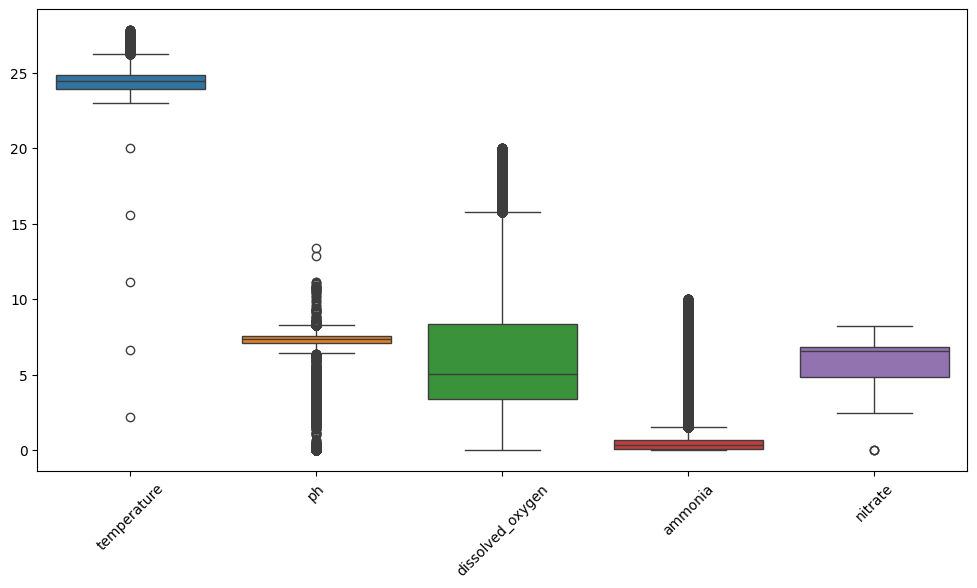

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data[['temperature','ph','dissolved_oxygen','ammonia','nitrate']])
plt.xticks(rotation=45)
plt.show()

correlation analysis

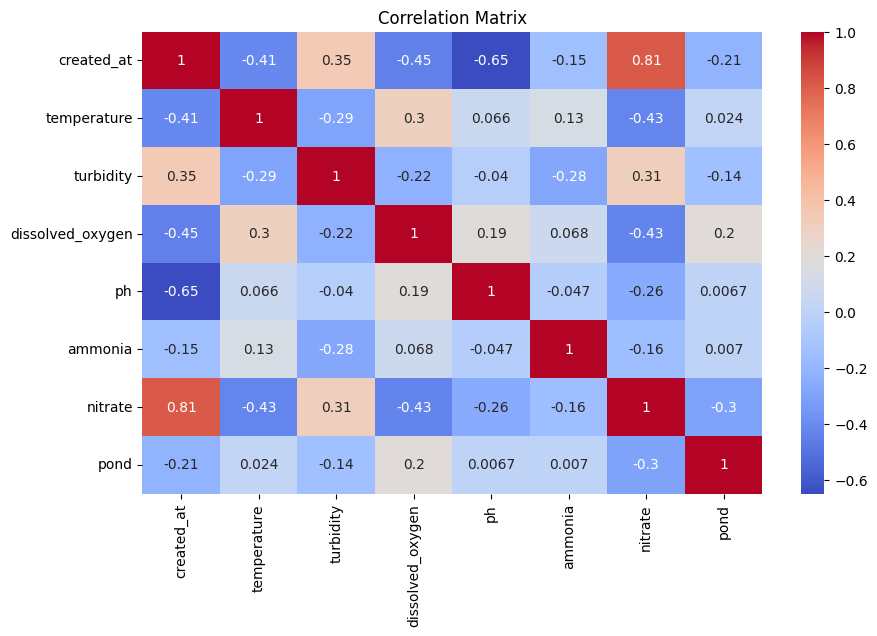

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

time series analysis

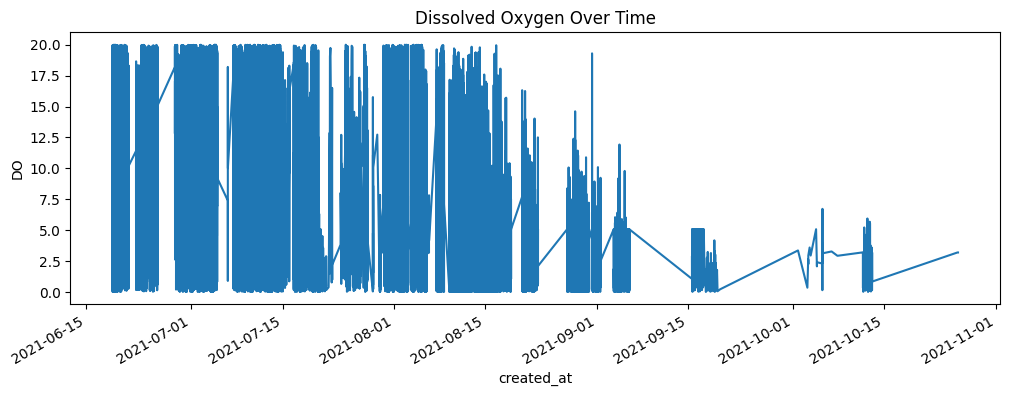

In [14]:
data.set_index('created_at')['dissolved_oxygen'].plot(figsize=(12,4))
plt.title("Dissolved Oxygen Over Time")
plt.ylabel("DO")
plt.show()

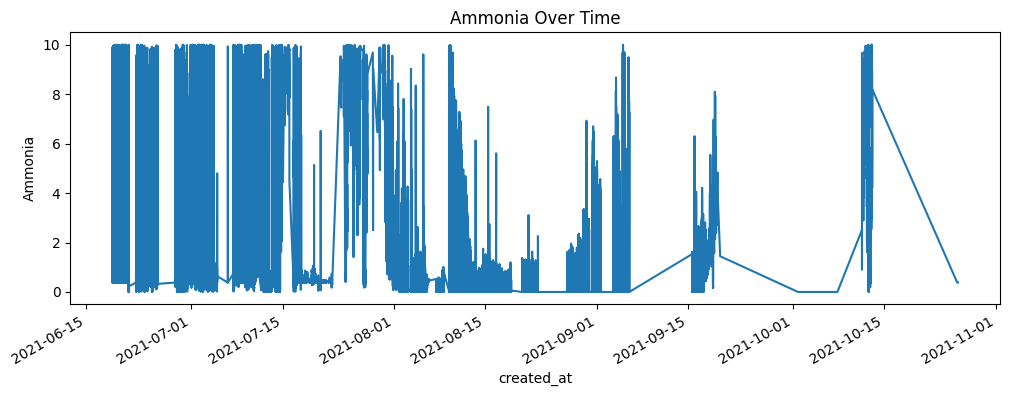

In [15]:
data.set_index('created_at')['ammonia'].plot(figsize=(12,4))
plt.title("Ammonia Over Time")
plt.ylabel("Ammonia")
plt.show()

In [16]:
data['fish_kill'] = (
    (data['dissolved_oxygen'] < 3) |
    (data['ammonia'] > 3) |
    (data['ph'] < 5) | (data['ph'] > 9)
).astype(int)

In [17]:
data['fish_kill'].value_counts()

fish_kill
0    179747
1     89962
Name: count, dtype: int64

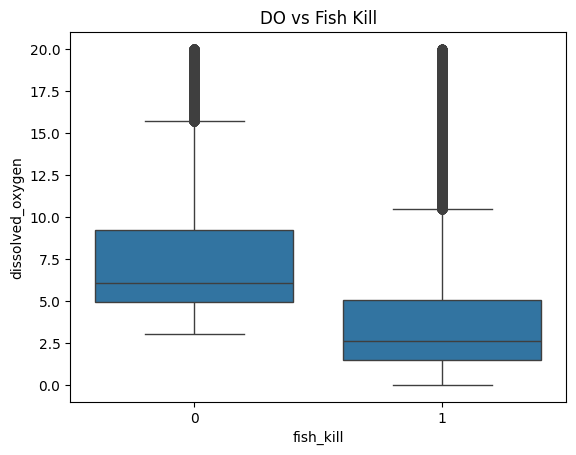

In [18]:
sns.boxplot(x='fish_kill', y='dissolved_oxygen', data=data)
plt.title("DO vs Fish Kill")
plt.show()

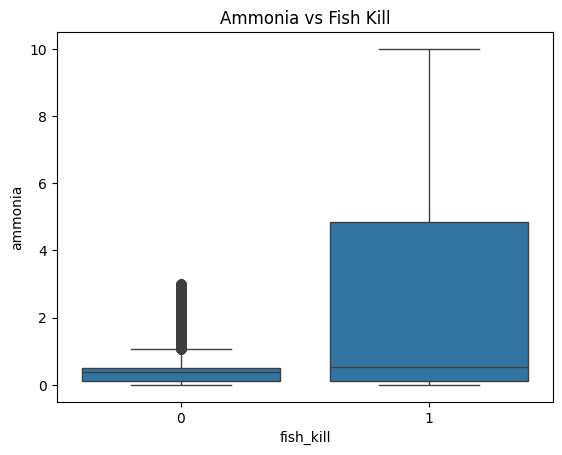

In [19]:
sns.boxplot(x='fish_kill', y='ammonia', data=data)
plt.title("Ammonia vs Fish Kill")
plt.show()

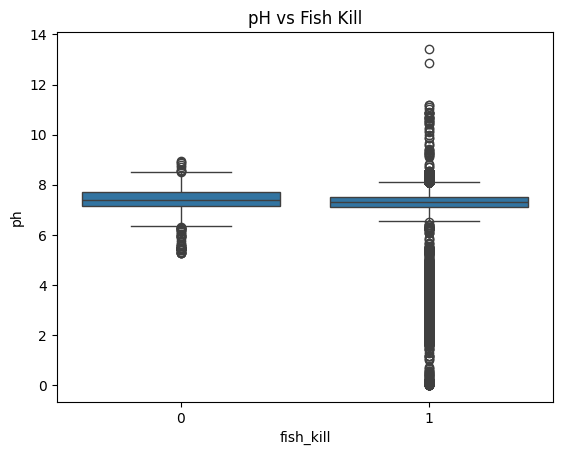

In [20]:
sns.boxplot(x='fish_kill', y='ph', data=data)
plt.title("pH vs Fish Kill")
plt.show()

pairplot

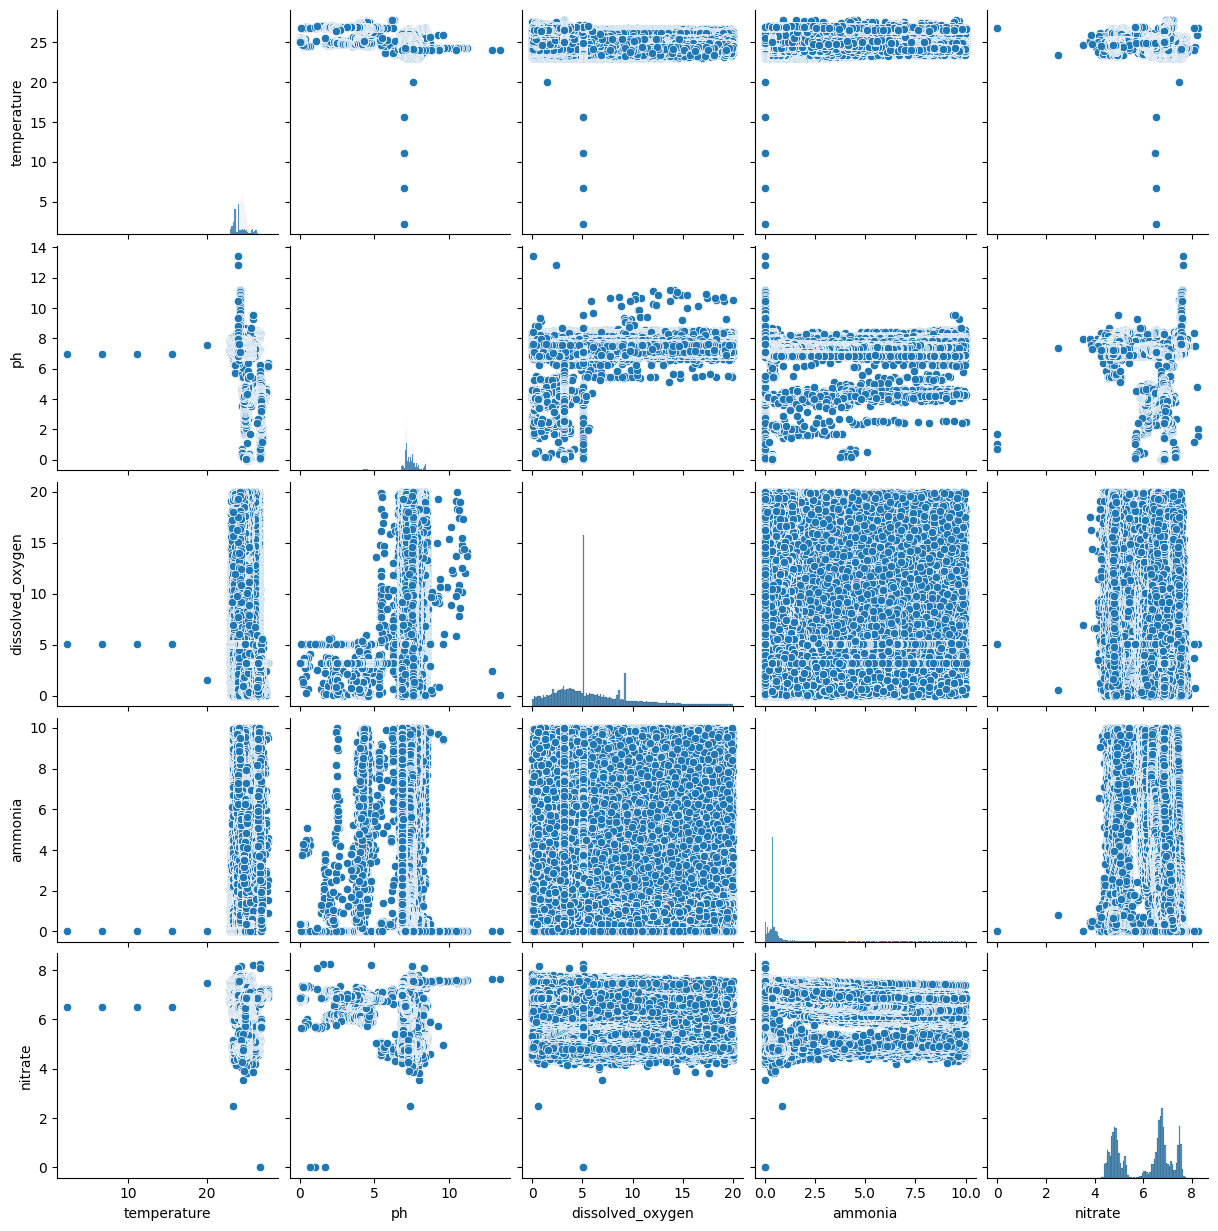

In [21]:
sns.pairplot(data[['temperature','ph','dissolved_oxygen','ammonia','nitrate']])
plt.show()

The exploratory data analysis reveals that the water quality parameters exhibit varying distributions and relationships that influence fish health conditions. Most variables show non-normal distributions with observable skewness, particularly in nitrate and ammonia levels. Correlation analysis indicates meaningful relationships among parameters, especially between dissolved oxygen and ammonia, which are known to impact aquatic life. Time-series visualization highlights fluctuations in key variables such as dissolved oxygen and ammonia, suggesting dynamic environmental conditions within the aquaponics system. Furthermore, comparative analysis using the fish kill indicator demonstrates that low dissolved oxygen levels, high ammonia concentrations, and extreme pH values are strongly associated with fish kill events. These findings validate the selection of features for predictive modeling and support the presence of threshold-based, non-linear effects in the dataset.

| Aspect            | Variable             | Observation                                      | Interpretation                                 | Implication for Model        |
| ----------------- | -------------------- | ------------------------------------------------ | ---------------------------------------------- | ---------------------------- |
| Distribution      | Temperature          | Narrow range (~23–25°C), few low outliers        | Stable environmental condition                 | Low predictive impact        |
| Distribution      | Turbidity            | Highly concentrated near high values (~90–100)   | Limited variability                            | Weak predictor               |
| Distribution      | Dissolved Oxygen     | Wide range (0–20), right-skewed                  | Strong variability, critical for fish survival | **Strong predictor**         |
| Distribution      | pH                   | Centered around ~7, with extreme outliers        | Mostly stable but occasional harmful levels    | Moderate predictor           |
| Distribution      | Ammonia              | Highly skewed, many low values, some high spikes | Indicates sudden toxic events                  | **Strong predictor**         |
| Distribution      | Nitrate              | Moderately spread, slightly skewed               | Nutrient variability present                   | Moderate predictor           |
| Correlation       | DO vs Temperature    | Moderate positive                                | Warmer water slightly increases DO variability | Secondary effect             |
| Correlation       | DO vs Nitrate        | Moderate negative                                | Nutrient activity affects oxygen               | Ecosystem interaction        |
| Correlation       | Ammonia vs Others    | Weak correlations                                | Independent toxic factor                       | Important standalone feature |
| Time-Series       | DO over time         | Sudden drops observed                            | Possible fish stress events                    | Critical for prediction      |
| Time-Series       | Ammonia over time    | Sudden spikes observed                           | Toxicity events occur intermittently           | Key trigger variable         |
| Feature vs Target | DO vs Fish Kill      | Lower DO in fish kill cases                      | Strong inverse relationship                    | **Primary indicator**        |
| Feature vs Target | Ammonia vs Fish Kill | Higher ammonia in fish kill cases                | Direct toxic effect                            | **Primary indicator**        |
| Feature vs Target | pH vs Fish Kill      | Extreme pH linked to fish kill                   | Threshold-based effect                         | Supporting feature           |
| Multivariate      | Pairplot             | Non-linear relationships visible                 | Variables interact complexly                   | Justifies ML models          |


Dissolved oxygen and ammonia are the most influential variables affecting fish kill conditions.
Fish kill events are associated with low DO and high ammonia, confirming known aquaculture thresholds.
Relationships between variables are non-linear, supporting the use of models like Random Forest and XGBoost.
Time-series patterns reveal sudden environmental changes, indicating the importance of temporal features.